# Ill-Conditioned Quadratic: BFGS vs L-BFGS vs M5-LBFGS

Reproduces the spectral-conditioning sensitivity study of the paper
*"A Limited-Memory M5 Quasi-Newton Method with Armijo Damping
Globalization"* (Section 7.6, Table 4).

Objective: $f(x) = \tfrac12 x^T A x$, with $A$ diagonal and eigenvalues
log-spaced in $[1, \kappa]$, so $\mathrm{cond}(A) = \kappa$ exactly.
The unique minimizer is $x^* = 0$, $f(x^*) = 0$.

Compared methods: **BFGS**, **L-BFGS**, **M5-LBFGS** only (the
operator-based M5 variant and the Newton-CG baseline used during
exploratory work are intentionally omitted -- they are not part of the
paper's Table 4).

Condition numbers swept: $\kappa \in \{10, 10^2, 10^3, 10^4\}$, at a
single common budget of `MAX_ITER = 2000` for every $\kappa$ (earlier
exploratory runs used a smaller budget of 1000 for $\kappa \in
\{10, 10^2\}$; this notebook fixes the budget at 2000 uniformly across
the whole sweep, as requested).


In [1]:
# ============================================================
# Part 1 : Imports and Global Settings
# ============================================================

import math
import time

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

torch.set_default_dtype(torch.float64)
torch.manual_seed(42)
np.random.seed(42)

print("=" * 65)
print(" Ill-Conditioned Quadratic : BFGS vs L-BFGS vs M5-LBFGS ")
print("=" * 65)
print("\nPyTorch Version :", torch.__version__)
print("NumPy Version   :", np.__version__)
print("Default dtype   :", torch.get_default_dtype())

# ---- Environment fingerprint, for exact reproducibility ----
# A reviewer with the SAME Python version, SAME PyTorch version, SAME
# platform, and the SAME number of CPU threads should reproduce every
# Iter. / Grad. evals / Final (f) / Final (|grad f|) / Status value in
# this notebook exactly -- there is no randomness anywhere in these
# optimizers or in the fixed problem definitions below, so the entire
# trajectory of every run is a deterministic function of these settings.
# CPU (s) is the one column NOT expected to match exactly even on an
# identical setup: wall-clock time also reflects OS scheduling, other
# running processes, and CPU thermal/frequency state, none of which are
# part of the algorithm -- that noise is exactly why converged runs are
# timed over multiple repetitions and averaged (see the runner harness),
# rather than reported from a single measurement.
import platform

print()
print("Python version     :", platform.python_version())
print("Platform           :", platform.platform())
print("CUDA available     :", torch.cuda.is_available(), "(informational only -- not used by this notebook)")
print("Default tensor device used throughout: CPU")
print("CPU threads (torch):", torch.get_num_threads())

_cpu_model = None
_total_ram = None
try:
    with open("/proc/cpuinfo") as _f:
        for _line in _f:
            if _line.lower().startswith("model name"):
                _cpu_model = _line.split(":", 1)[1].strip()
                break
except (FileNotFoundError, OSError):
    pass
if _cpu_model is None:
    _cpu_model = platform.processor() or "unavailable"

try:
    with open("/proc/meminfo") as _f:
        for _line in _f:
            if _line.startswith("MemTotal"):
                _total_ram = _line.split(":", 1)[1].strip()
                break
except (FileNotFoundError, OSError):
    pass

print("CPU model          :", _cpu_model)
print("Total RAM          :", _total_ram if _total_ram else "unavailable")


 Ill-Conditioned Quadratic : BFGS vs L-BFGS vs M5-LBFGS 

PyTorch Version : 2.14.0+cu130
NumPy Version   : 2.4.4
Default dtype   : torch.float64

Python version     : 3.12.3
Platform           : Linux-6.18.44-fc-v32-x86_64-with-glibc2.39
CUDA available     : False (informational only -- not used by this notebook)
Default tensor device used throughout: CPU
CPU threads (torch): 1
CPU model          : Intel(R) Xeon(R) Processor @ 2.10GHz
Total RAM          : 4091944 kB


In [2]:
# ============================================================
# Part 2 : Optimizer Hyperparameters (fixed across every kappa)
# ============================================================

DIMENSION = 100            # problem dimension n (paper default)
MEMORY_SIZE = 20           # L-BFGS memory size m (paper default)

KAPPAS = [10, 100, 1000, 10000]     # condition numbers to sweep

# A SINGLE, COMMON iteration budget for every kappa in the sweep, as
# requested -- rather than the smaller 1000-iteration budget used for
# kappa in {10, 100} during earlier exploratory work.
MAX_ITER = 2000
TOL = 1e-6                 # convergence tolerance on ||grad f||

# ---- Strong-Wolfe constants, used ONLY by BFGS / L-BFGS ----
SW_C1 = 1e-4
SW_C2 = 0.9

# ---- Damped-Armijo constants, used ONLY by M5-LBFGS ----
# The damping parameter alpha lives INSIDE the multi-stage M5
# construction (paper Eq. 18-20), so every backtracking trial
# recomputes the whole predictor-corrector recursion at the new
# alpha -- it is NOT a classical line search on a fixed direction.
ARMIJO_C1 = 1e-4           # sufficient-decrease constant, must be < 1/2
RHO = 0.5                  # geometric backtracking reduction factor
MAX_BACKTRACK = 60         # safety cap on backtracking trials per iteration

CURVATURE_EPS = 1e-10      # epsilon_curv : L-BFGS curvature-pair acceptance threshold

TIMING_REPEATS = 10        # repeat each run this many times and average the
                            # CPU time only (iteration/eval counts are
                            # deterministic here, so a single run fixes them)

assert 0 < ARMIJO_C1 < 0.5, "the paper's Armijo condition requires 0 < c1 < 1/2"
assert 0 < RHO < 1

print("Optimizer Hyperparameters\n")
print(f"Dimension n                : {DIMENSION}")
print(f"Memory size m               : {MEMORY_SIZE}")
print(f"Condition numbers (kappa)   : {KAPPAS}")
print(f"Maximum Iterations          : {MAX_ITER}  (fixed for every kappa)")
print(f"Tolerance                   : {TOL}")
print(f"Strong-Wolfe (c1, c2)       : ({SW_C1}, {SW_C2})   [BFGS / L-BFGS]")
print(f"Damped-Armijo (c1, rho)     : ({ARMIJO_C1}, {RHO})   [M5-LBFGS]")
print(f"Max backtracking trials     : {MAX_BACKTRACK}")
print(f"Curvature acceptance eps    : {CURVATURE_EPS}")
print(f"Timing repeats per run      : {TIMING_REPEATS}")


Optimizer Hyperparameters

Dimension n                : 100
Memory size m               : 20
Condition numbers (kappa)   : [10, 100, 1000, 10000]
Maximum Iterations          : 2000  (fixed for every kappa)
Tolerance                   : 1e-06
Strong-Wolfe (c1, c2)       : (0.0001, 0.9)   [BFGS / L-BFGS]
Damped-Armijo (c1, rho)     : (0.0001, 0.5)   [M5-LBFGS]
Max backtracking trials     : 60
Curvature acceptance eps    : 1e-10
Timing repeats per run      : 10


In [3]:
# ============================================================
# Part 3 : Evaluation Counters + Wrapped Objective / Gradient
# ============================================================
# Every optimizer below calls ONLY objective(x) and gradient(x) -- never
# a problem's raw formula directly -- so "Grad. evals" in the results
# table is an exact, comparable count across all three methods. For
# M5-LBFGS this matters even more: every backtracking TRIAL recomputes
# gradients at the trial's own intermediate points y_k(alpha), z_k(alpha),
# so the count reflects the O(N_bt,k) trial cost from the paper's
# complexity analysis (Section 6), not just one evaluation per accepted
# outer iteration.

def make_wrapped(objective_raw):
    """Return (objective, gradient, counters) wrapping a raw f(x) so
    every call increments a fresh, private counters dict."""
    counters = {"obj_evals": 0, "grad_evals": 0}

    def objective(x):
        counters["obj_evals"] += 1
        return objective_raw(x)

    def gradient(x):
        counters["grad_evals"] += 1
        f = objective_raw(x)
        g = torch.autograd.grad(outputs=f, inputs=x, create_graph=False)[0]
        return g

    return objective, gradient, counters

print("Evaluation counters ready.")


Evaluation counters ready.


In [4]:
# ============================================================
# Part 4 : L-BFGS Memory and Two-Loop Recursion
# ============================================================

class LBFGSMemory:
    """Stores the correction pairs (s, r) required by the L-BFGS
    two-loop recursion, together with the gamma_k initial scaling."""

    def __init__(self, memory_size=MEMORY_SIZE):
        self.memory_size = memory_size
        self.s_list = []
        self.r_list = []

    def update(self, s, r):
        self.s_list.append(s.detach().clone())
        self.r_list.append(r.detach().clone())
        if len(self.s_list) > self.memory_size:
            self.s_list.pop(0)
            self.r_list.pop(0)

    def clear(self):
        self.s_list.clear()
        self.r_list.clear()

    def size(self):
        return len(self.s_list)

    def gamma(self):
        """Initial scaling gamma_k = (s^T r) / (r^T r); returns 1.0 if
        the memory is empty (H^(0) = I)."""
        if self.size() == 0:
            return torch.tensor(1.0, dtype=torch.float64)
        s, r = self.s_list[-1], self.r_list[-1]
        return torch.dot(s, r) / torch.dot(r, r)


def two_loop_recursion(g, memory):
    """Compute H_k g using the standard L-BFGS two-loop recursion.
    Returns g unchanged (H_k = I) if the memory is empty."""
    if memory.size() == 0:
        return g.clone()

    q = g.clone()
    alpha_list, rho_list = [], []

    for s, r in zip(reversed(memory.s_list), reversed(memory.r_list)):
        rho_i = 1.0 / torch.dot(r, s)
        alpha_i = rho_i * torch.dot(s, q)
        q = q - alpha_i * r
        alpha_list.append(alpha_i)
        rho_list.append(rho_i)

    result = memory.gamma() * q

    alpha_list.reverse()
    rho_list.reverse()

    for s, r, alpha_i, rho_i in zip(memory.s_list, memory.r_list, alpha_list, rho_list):
        beta = rho_i * torch.dot(r, result)
        result = result + s * (alpha_i - beta)

    return result

print("L-BFGS memory / two-loop recursion ready.")


L-BFGS memory / two-loop recursion ready.


In [5]:
# ============================================================
# Part 5 : Strong-Wolfe Line Search (used only by BFGS / L-BFGS)
# ============================================================
# Standard bracket + bisection-zoom strong-Wolfe search (Nocedal &
# Wright, Algorithms 3.5-3.6), made robust to non-finite trial values.
# Assumes a FIXED search direction d; NOT used for M5-LBFGS (see Part 8),
# which recomputes the direction itself as the damping parameter shrinks.

def _finite(v):
    return math.isfinite(v)


def strong_wolfe_line_search(x, d, f0, g0, objective, gradient,
                              c1=SW_C1, c2=SW_C2, alpha_max=1e8,
                              max_iter=50, zoom_iter=80):
    def trial(alpha):
        x_new = (x + alpha * d).detach().requires_grad_(True)
        phi = objective(x_new).item()
        return x_new, phi

    dphi0 = torch.dot(g0, d).item()
    if dphi0 >= 0:
        return None

    def zoom(alpha_lo, alpha_hi, phi_lo):
        alpha = alpha_lo
        for _ in range(zoom_iter):
            alpha = 0.5 * (alpha_lo + alpha_hi)
            x_new, phi = trial(alpha)
            if (not _finite(phi)) or phi > f0 + c1 * alpha * dphi0 or phi >= phi_lo:
                alpha_hi = alpha
            else:
                g_new = gradient(x_new)
                dphi = torch.dot(g_new, d).item()
                if abs(dphi) <= -c2 * dphi0:
                    return alpha, x_new, phi, g_new
                if dphi * (alpha_hi - alpha_lo) >= 0:
                    alpha_hi = alpha_lo
                alpha_lo = alpha
                phi_lo = phi
            if alpha_hi - alpha_lo < 1e-300:
                break
        x_new, phi = trial(alpha_lo)
        g_new = gradient(x_new)
        return alpha_lo, x_new, phi, g_new

    alpha_prev = 0.0
    phi_prev = f0
    alpha = 1.0

    for i in range(max_iter):
        x_new, phi = trial(alpha)
        if (not _finite(phi)) or phi > f0 + c1 * alpha * dphi0 or (i > 0 and phi >= phi_prev):
            return zoom(alpha_prev, alpha, phi_prev)
        g_new = gradient(x_new)
        dphi = torch.dot(g_new, d).item()
        if abs(dphi) <= -c2 * dphi0:
            return alpha, x_new, phi, g_new
        if dphi >= 0:
            return zoom(alpha, alpha_prev, phi)
        alpha_prev, phi_prev = alpha, phi
        alpha = min(2.0 * alpha, alpha_max)

    x_new, phi = trial(alpha)
    g_new = gradient(x_new)
    return alpha, x_new, phi, g_new


def accept_direction(x, d, g, f0, objective, gradient, c1=SW_C1, c2=SW_C2, min_alpha=1e-14):
    if not torch.isfinite(d).all():
        return None
    if torch.dot(g, d).item() >= 0:
        return None

    result = strong_wolfe_line_search(x, d, f0, g, objective, gradient, c1, c2)
    if result is None:
        return None

    alpha, x_new, f_new, g_new = result
    if alpha < min_alpha or not _finite(f_new):
        return None

    return alpha, x_new, f_new, g_new

print("Strong-Wolfe line search ready.")


Strong-Wolfe line search ready.


In [6]:
# ============================================================
# Part 6 : Classical BFGS (dense, strong-Wolfe globalized)
# ============================================================

def bfgs_sw(x0, objective, gradient, max_iter=MAX_ITER, tol=TOL, c1=SW_C1, c2=SW_C2):
    x = x0.clone().detach().requires_grad_(True)
    n = x.numel()

    H = torch.eye(n, dtype=torch.float64)
    I = torch.eye(n, dtype=torch.float64)

    g = gradient(x)

    history = []
    converged = False
    reason = "Maximum iterations reached"
    k = 0

    for k in range(max_iter):
        f = objective(x).item()
        gn = torch.norm(g).item()
        history.append({"Iteration": k, "Objective": f, "Gradient Norm": gn})

        if gn < tol:
            converged = True
            reason = "Gradient tolerance reached"
            break

        d = -(H @ g)
        result = accept_direction(x, d, g, f, objective, gradient, c1, c2)
        if result is None:
            result = accept_direction(x, -g, g, f, objective, gradient, c1, c2)
        if result is None:
            reason = "Line search failed (not descent)"
            break

        alpha, x_new, f_new, g_new = result
        s = x_new.detach() - x.detach()
        y = g_new.detach() - g.detach()
        sy = torch.dot(s, y).item()

        if sy > CURVATURE_EPS:
            rho = 1.0 / sy
            H = (I - rho * torch.outer(s, y)) @ H @ (I - rho * torch.outer(y, s)) \
                + rho * torch.outer(s, s)

        x, g = x_new, g_new

    return x, history, converged, reason, k

print("BFGS (strong-Wolfe) ready.")


BFGS (strong-Wolfe) ready.


In [7]:
# ============================================================
# Part 7 : Classical L-BFGS (strong-Wolfe globalized)
# ============================================================

def lbfgs_sw(x0, objective, gradient, memory_size=MEMORY_SIZE, max_iter=MAX_ITER,
             tol=TOL, c1=SW_C1, c2=SW_C2):
    x = x0.clone().detach().requires_grad_(True)
    memory = LBFGSMemory(memory_size)

    g = gradient(x)

    history = []
    converged = False
    reason = "Maximum iterations reached"
    k = 0

    for k in range(max_iter):
        f = objective(x).item()
        gn = torch.norm(g).item()
        history.append({"Iteration": k, "Objective": f, "Gradient Norm": gn})

        if gn < tol:
            converged = True
            reason = "Gradient tolerance reached"
            break

        Hg = two_loop_recursion(g, memory)
        d = -Hg

        result = accept_direction(x, d, g, f, objective, gradient, c1, c2)
        if result is None:
            result = accept_direction(x, -g, g, f, objective, gradient, c1, c2)
        if result is None:
            reason = "Line search failed (not descent)"
            break

        alpha, x_new, f_new, g_new = result
        s = x_new.detach() - x.detach()
        r = g_new.detach() - g.detach()

        if torch.dot(s, r).item() > CURVATURE_EPS:
            memory.update(s, r)

        x, g = x_new, g_new

    return x, history, converged, reason, k

print("L-BFGS (strong-Wolfe) ready.")


L-BFGS (strong-Wolfe) ready.


In [8]:
# ============================================================
# Part 8 : M5-LBFGS -- Damped Armijo Backtracking Core + Construction
# ============================================================
# damped_armijo_backtrack implements Definition 4.7 / Algorithm 2: the
# damping parameter alpha is fed to construct_fn(x, g, memory, alpha),
# which RECOMPUTES THE ENTIRE multi-stage predictor-corrector recursion
# at that alpha (Eq. 18-20) -- it is not a scalar multiplier applied to
# one fixed pre-computed vector. Trial parameters are alpha_j = rho^j,
# j = 0, 1, 2, ..., and the accepted alpha is the first for which both
# the descent condition and the Armijo sufficient-decrease condition
# hold.

def m5_displacement(x, g, memory, alpha, gradient):
    """Complete damped M5 construction, Eq. (18)-(20), at parameter alpha:

        y_k(alpha) = x_k - alpha * H_k g_k
        z_k(alpha) = y_k(alpha) - 5 alpha * H_k grad f(y_k(alpha))
        xhat_{k+1}(alpha) = z_k(alpha)
                             - (alpha/5) * H_k[-16 grad f(y_k(alpha)) + grad f(z_k(alpha))]
        d_k(alpha) = xhat_{k+1}(alpha) - x_k

    At alpha = 1 this reduces exactly to the raw construction (7)-(10).
    """
    Hg = two_loop_recursion(g, memory)
    y = (x.detach() - alpha * Hg).requires_grad_(True)
    gy = gradient(y)

    Hgy = two_loop_recursion(gy, memory)
    z = (y.detach() - 5.0 * alpha * Hgy).requires_grad_(True)
    gz = gradient(z)

    Hgz = two_loop_recursion(gz, memory)
    x_hat = z.detach() - (alpha / 5.0) * (-16.0 * Hgy + Hgz)

    return x_hat - x.detach()


def damped_armijo_backtrack(x, g, f0, memory, construct_fn, objective,
                             c1=ARMIJO_C1, rho=RHO, max_trials=MAX_BACKTRACK):
    alpha = 1.0
    for _ in range(max_trials):
        d = construct_fn(x, g, memory, alpha)
        if torch.isfinite(d).all():
            gTd = torch.dot(g, d).item()
            if gTd < 0:
                x_new = (x.detach() + d).detach().requires_grad_(True)
                f_new = objective(x_new).item()
                if math.isfinite(f_new) and f_new <= f0 + c1 * gTd:
                    return alpha, d, x_new, f_new
        alpha *= rho
    return None


print("Damped Armijo backtracking core (Definition 4.7 / Algorithm 2) ready.")


Damped Armijo backtracking core (Definition 4.7 / Algorithm 2) ready.


In [9]:
# ============================================================
# Part 9 : M5-LBFGS -- Full Iteration
# ============================================================
# Implements Algorithm 2 literally: if damped_armijo_backtrack exhausts
# MAX_BACKTRACK trials without an acceptance -- which Theorem 4.9 proves
# will not happen at a nonstationary point under the paper's stated
# assumptions -- the run terminates with reason =
# "Damped Armijo backtracking failed (Algorithm 2)" rather than
# substituting a different step. No fallback / safety-net code path.

def m5_lbfgs(x0, objective, gradient, memory_size=MEMORY_SIZE, max_iter=MAX_ITER,
             tol=TOL, c1=ARMIJO_C1, rho=RHO, max_backtrack=MAX_BACKTRACK,
             curvature_eps=CURVATURE_EPS):

    x = x0.clone().detach().requires_grad_(True)
    memory = LBFGSMemory(memory_size)

    g = gradient(x)

    history = []
    converged = False
    reason = "Maximum iterations reached"
    k = 0

    def construct_fn(xx, gg, mem, a):
        return m5_displacement(xx, gg, mem, a, gradient)

    for k in range(max_iter):
        f = objective(x).item()
        gn = torch.norm(g).item()
        history.append({"Iteration": k, "Objective": f, "Gradient Norm": gn})

        if gn < tol:
            converged = True
            reason = "Gradient tolerance reached"
            break

        result = damped_armijo_backtrack(
            x, g, f, memory, construct_fn, objective, c1=c1, rho=rho, max_trials=max_backtrack)

        if result is None:
            reason = "Damped Armijo backtracking failed (Algorithm 2)"
            break

        alpha, d, x_new, f_new = result
        g_new = gradient(x_new)

        s = x_new.detach() - x.detach()
        r = g_new.detach() - g.detach()

        if torch.dot(s, r).item() > curvature_eps:
            memory.update(s, r)

        x, g = x_new, g_new

    return x, history, converged, reason, k

print("M5-LBFGS (damped, Algorithm 2) ready.")

METHODS = [
    ("BFGS", bfgs_sw),
    ("L-BFGS", lbfgs_sw),
    ("M5-LBFGS", m5_lbfgs),
]


M5-LBFGS (damped, Algorithm 2) ready.


## Ill-Conditioned Quadratic Problem Family

$f(x) = \tfrac12 x^T A x$, $A = \mathrm{diag}(\lambda_1, \dots, \lambda_n)$
with $\lambda_i$ log-spaced in $[1, \kappa]$, so $\mathrm{cond}(A) =
\kappa$ exactly. Starting point $x_0 = (1, \dots, 1)$, unique minimizer
$x^* = 0$, $f(x^*) = 0$.


In [10]:
# ============================================================
# Part 10 : Ill-Conditioned Quadratic Problem Builder
# ============================================================

def build_ill_conditioned_quadratic(kappa, dim=DIMENSION):
    """Return a problem dict for f(x) = 1/2 x^T A x with cond(A) = kappa."""
    exponent = math.log10(kappa)
    eigenvalues = torch.logspace(0.0, exponent, dim, dtype=torch.float64)
    A = torch.diag(eigenvalues)

    def objective_raw(x):
        return 0.5 * torch.dot(x, A @ x)

    x0 = torch.ones(dim, dtype=torch.float64, requires_grad=True)

    lambda_min = torch.min(eigenvalues).item()
    lambda_max = torch.max(eigenvalues).item()

    return {
        "name": f"Ill-Conditioned Quadratic (kappa={kappa:g})",
        "kappa": kappa,
        "kappa_actual": lambda_max / lambda_min,
        "n": dim,
        "x0": x0,
        "f": objective_raw,
        "f_min": 0.0,
    }

for kappa in KAPPAS:
    p = build_ill_conditioned_quadratic(kappa)
    print(f"kappa = {kappa:>6g}   cond(A) actual = {p['kappa_actual']:.6e}   "
          f"f(x0) = {p['f'](p['x0']).item():.6e}")


kappa =     10   cond(A) actual = 1.000000e+01   f(x0) = 1.962369e+02
kappa =    100   cond(A) actual = 1.000000e+02   f(x0) = 1.089572e+03
kappa =   1000   cond(A) actual = 1.000000e+03   f(x0) = 7.411847e+03
kappa =  10000   cond(A) actual = 1.000000e+04   f(x0) = 5.627757e+04


In [11]:
# ============================================================
# Part 11 : Runner Harness
# ============================================================

def run_method(name, fn, problem, timing_repeats=TIMING_REPEATS, **kwargs):
    """Run one optimizer on one problem and return a results row plus
    its convergence history.

    CPU-timing strategy: the first (counting) run is always timed. If
    that run CONVERGED, timing_repeats - 1 additional timed repeats are
    added and averaged in, for a stable CPU-time estimate (iteration /
    evaluation counts are deterministic, so a single run already fixes
    those). If the run did NOT converge -- i.e. it burned through the
    full max_iter budget (this happens for L-BFGS and M5-LBFGS at
    kappa = 10000) -- it is timed ONCE only: repeating an
    already-at-the-iteration-cap run several more times just multiplies
    the most expensive case in the sweep for very little additional
    precision."""
    x0 = problem["x0"]
    objective, gradient, counters = make_wrapped(problem["f"])

    t0 = time.time()
    out = fn(x0, objective, gradient, **kwargs)
    t1 = time.time()
    x_final, history = out[0], out[1]
    converged, reason, k = out[2], out[3], out[4]
    grad_evals = counters["grad_evals"]

    times = [t1 - t0]
    if converged:
        for _ in range(timing_repeats - 1):
            t_obj, t_grad, _ = make_wrapped(problem["f"])
            t0 = time.time()
            fn(x0, t_obj, t_grad, **kwargs)
            t1 = time.time()
            times.append(t1 - t0)
    cpu_time = float(np.mean(times))

    last = history[-1]

    row = {
        "kappa": problem["kappa"],
        "Method": name,
        "Iter.": len(history) - 1,
        "CPU (s)": round(cpu_time, 4),
        "Grad. evals": grad_evals,
        "Final (f)": last["Objective"],
        "Final (|grad f|)": last["Gradient Norm"],
        "Converged": converged,
        "Termination": reason,
    }
    return row, history, x_final

print("Runner harness ready.")


Runner harness ready.


In [12]:
# ============================================================
# Part 12 : Run BFGS / L-BFGS / M5-LBFGS for Every Kappa
# ============================================================
# MAX_ITER = 2000 is used uniformly for every kappa in KAPPAS (Part 2).

MASTER_RESULTS = []
HISTORIES = {}   # HISTORIES[(kappa, method_name)] -> history list

print("=" * 65)
print(f" Running {len(METHODS)} methods x {len(KAPPAS)} condition numbers "
      f"(max_iter = {MAX_ITER} for every kappa) ")
print("=" * 65)

for kappa in KAPPAS:
    problem = build_ill_conditioned_quadratic(kappa)
    print(f"\nkappa(A) = {kappa:g}  (actual: {problem['kappa_actual']:.6e})")
    for method_name, fn in METHODS:
        kwargs = dict(max_iter=MAX_ITER, tol=TOL)
        if method_name != "BFGS":
            kwargs["memory_size"] = MEMORY_SIZE
        row, history, x_final = run_method(method_name, fn, problem, timing_repeats=TIMING_REPEATS, **kwargs)
        MASTER_RESULTS.append(row)
        HISTORIES[(kappa, method_name)] = history
        print(f"  {method_name:10s} iter={row['Iter.']:5d}  CPU={row['CPU (s)']:.4f}s  "
              f"grad_ev={row['Grad. evals']:6d}  |g_final|={row['Final (|grad f|)']:.4e}  "
              f"{'C' if row['Converged'] else 'NC'}")

print("\nAll runs complete.")


 Running 3 methods x 4 condition numbers (max_iter = 2000 for every kappa) 

kappa(A) = 10  (actual: 1.000000e+01)


  BFGS       iter=   56  CPU=0.0269s  grad_ev=    57  |g_final|=9.8459e-07  C
  L-BFGS     iter=   30  CPU=0.0130s  grad_ev=    33  |g_final|=7.8134e-07  C


  M5-LBFGS   iter=   16  CPU=0.0206s  grad_ev=    79  |g_final|=2.4264e-07  C

kappa(A) = 100  (actual: 1.000000e+02)


  BFGS       iter=   84  CPU=0.0286s  grad_ev=    89  |g_final|=8.2796e-07  C


  L-BFGS     iter=  121  CPU=0.0709s  grad_ev=   188  |g_final|=9.7630e-07  C


...

  L-BFGS     iter=  610  CPU=0.4036s  grad_ev=  1191  |g_final|=9.9832e-07  C


  M5-LBFGS   iter=  651  CPU=1.1676s  grad_ev=  2194  |g_final|=9.9909e-07  C

kappa(A) = 10000  (actual: 1.000000e+04)


  BFGS       iter=  107  CPU=0.0426s  grad_ev=   114  |g_final|=6.4504e-07  C


  L-BFGS     iter= 1999  CPU=1.2992s  grad_ev=  4034  |g_final|=1.4127e-05  NC


  M5-LBFGS   iter= 1999  CPU=9.6081s  grad_ev= 15399  |g_final|=3.7221e-06  NC

All runs complete.


In [13]:
# ============================================================
# Part 13 : Results Table  (Table 4 layout)
# ============================================================

master_df = pd.DataFrame(MASTER_RESULTS)

display_cols = ["kappa", "Method", "Iter.", "CPU (s)", "Grad. evals",
                 "Final (f)", "Final (|grad f|)", "Converged"]
table4 = master_df[display_cols].copy()
table4["Stat."] = np.where(table4["Converged"], "C", "NC")
table4 = table4.drop(columns=["Converged"])

pd.set_option("display.width", 160)
print("Table 4 -- Ill-conditioned quadratic results (n = {}, m = {})\n".format(DIMENSION, MEMORY_SIZE))
print(table4.to_string(index=False))

csv_path = "table4_ill_conditioned_quadratic.csv"
table4.to_csv(csv_path, index=False)
print(f"\nSaved to: {csv_path}")


Table 4 -- Ill-conditioned quadratic results (n = 100, m = 20)

 kappa   Method  Iter.  CPU (s)  Grad. evals    Final (f)  Final (|grad f|) Stat.
    10     BFGS     56   0.0269           57 1.117227e-13      9.845872e-07     C
    10   L-BFGS     30   0.0130           33 1.312016e-13      7.813363e-07     C
    10 M5-LBFGS     16   0.0206           79 7.417437e-15      2.426405e-07     C
   100     BFGS     84   0.0286           89 3.970808e-14      8.279555e-07     C
   100   L-BFGS    121   0.0709          188 3.589255e-13      9.762964e-07     C
   100 M5-LBFGS     59   0.1125          248 3.006158e-13      9.198568e-07     C
  1000     BFGS    100   0.0357          107 1.260702e-14      7.406383e-07     C
  1000   L-BFGS    610   0.4036         1191 3.706813e-13      9.983152e-07     C
  1000 M5-LBFGS    651   1.1676         2194 3.815592e-13      9.990933e-07     C
 10000     BFGS    107   0.0426          114 7.735827e-16      6.450354e-07     C
 10000   L-BFGS   1999   1.2992   

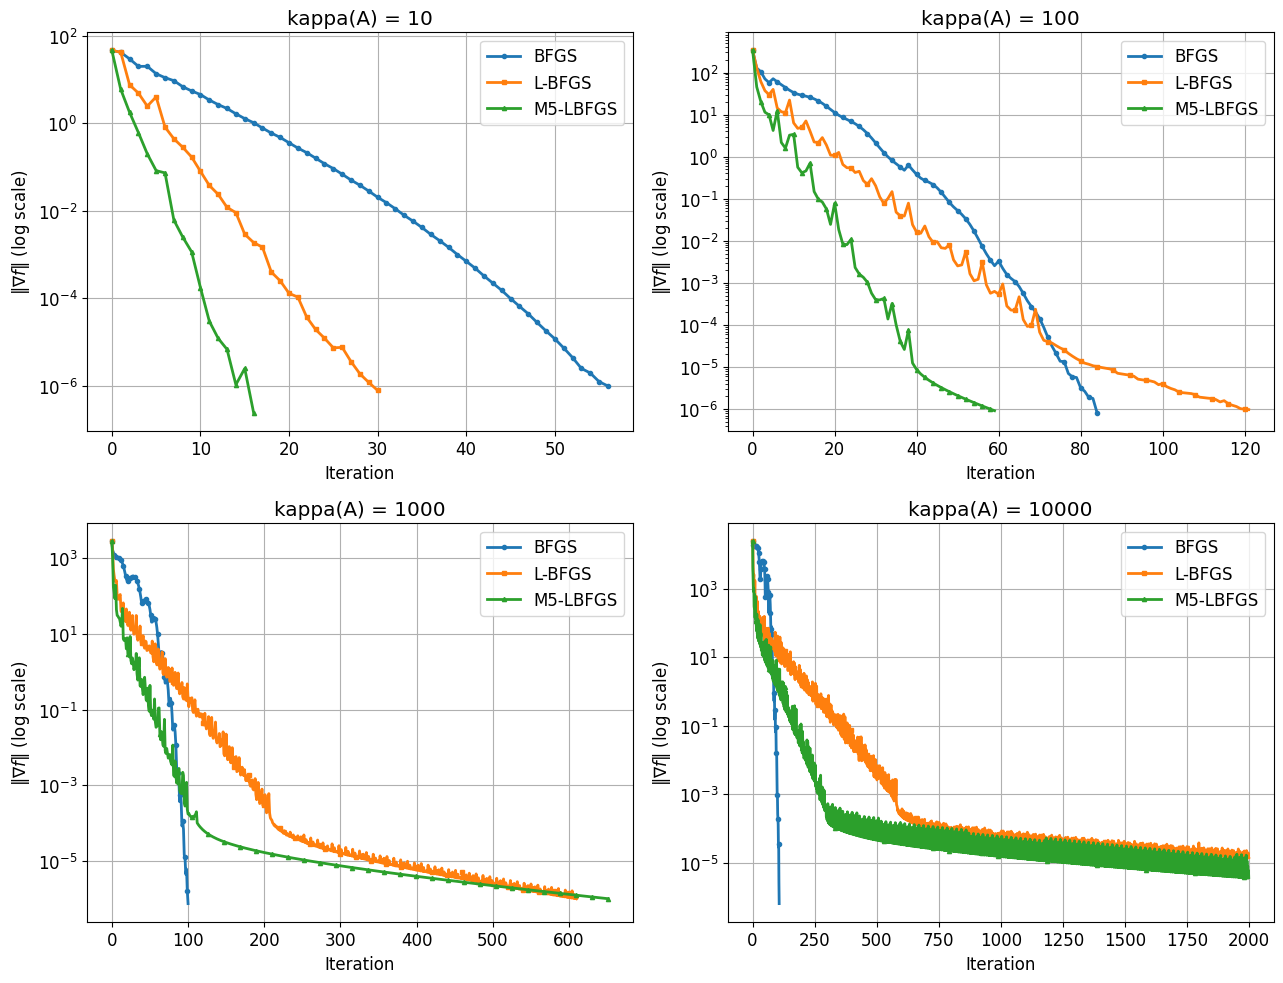

In [14]:
# ============================================================
# Part 14 : Convergence Plots -- Gradient Norm vs Iteration
# ============================================================
# One panel per kappa, all three methods overlaid (log scale).

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
markers = {"BFGS": "o", "L-BFGS": "s", "M5-LBFGS": "^"}

for ax, kappa in zip(axes.ravel(), KAPPAS):
    for method_name, _ in METHODS:
        hist = HISTORIES[(kappa, method_name)]
        hdf = pd.DataFrame(hist)
        ax.semilogy(hdf["Iteration"], hdf["Gradient Norm"].clip(lower=1e-300),
                    linewidth=2, marker=markers.get(method_name, "o"), markersize=3,
                    markevery=max(1, len(hdf) // 30), label=method_name)
    ax.set_title(f"kappa(A) = {kappa:g}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\|\nabla f\|$ (log scale)")
    ax.legend()

plt.tight_layout()
plt.savefig("ill_conditioned_convergence.png", dpi=150)
plt.show()


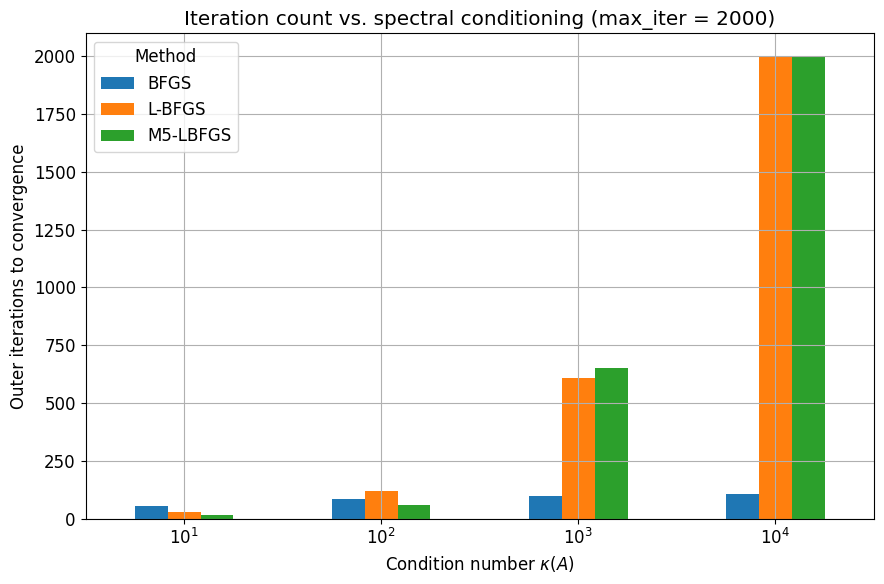

Method  BFGS  L-BFGS  M5-LBFGS
kappa                         
10        56      30        16
100       84     121        59
1000     100     610       651
10000    107    1999      1999


In [15]:
# ============================================================
# Part 15 : Iteration-Count Summary Bar Chart
# ============================================================

pivot_iter = master_df.pivot(index="kappa", columns="Method", values="Iter.")
pivot_iter = pivot_iter[[m for m, _ in METHODS]]  # keep BFGS/L-BFGS/M5-LBFGS order

ax = pivot_iter.plot(kind="bar", figsize=(9, 6),
                      color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_xlabel(r"Condition number $\kappa(A)$")
ax.set_ylabel("Outer iterations to convergence")
ax.set_title(f"Iteration count vs. spectral conditioning (max_iter = {MAX_ITER})")
ax.set_xticklabels([f"$10^{{{int(round(math.log10(k)))}}}$" for k in pivot_iter.index], rotation=0)
plt.tight_layout()
plt.savefig("ill_conditioned_iteration_summary.png", dpi=150)
plt.show()

print(pivot_iter.to_string())


## Notes

- **Table 4 analogue**: `table4` / `table4_ill_conditioned_quadratic.csv`
  (Part 13) gives the full per-kappa, per-method table in the same
  layout as the paper's Table 4.
- Only **BFGS**, **L-BFGS**, and **M5-LBFGS** are compared here. The
  operator-based M5 variant and the Newton-CG baseline used in earlier
  exploratory notebooks are intentionally not included -- they are not
  part of the paper's reported results.
- `MAX_ITER = 2000` is applied uniformly to every $\kappa$ in the sweep
  (Part 2), rather than the smaller 1000-iteration budget used for
  $\kappa \in \{10, 10^2\}$ in earlier exploratory runs.
- Iteration counts (and, more sensitively, the exact backtracking
  trajectory of M5-LBFGS) can drift slightly across machines/PyTorch
  versions due to floating-point rounding differences that occasionally
  flip a borderline Armijo-acceptance or curvature-retention decision.
  BFGS (no backtracking-heavy branching) reproduces essentially
  bit-for-bit across environments; L-BFGS and, more so, M5-LBFGS can
  show minor (environment-dependent) differences in iteration count
  even though the algorithm itself is fully deterministic.
